In [1]:
import albumentations as A
import numpy as np
import cv2
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import yaml
import os
import random
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
#!pip install ultralytics
#from ultralytics.utils import metrics

In [2]:
%pip install ultralytics
import ultralytics
ultralytics.checks()
from ultralytics import YOLO

Ultralytics YOLOv8.2.92 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 5845.9/8062.4 GB disk)


In [3]:
def load_data(directory):
    images = []
    labels = []
    for class_name in os.listdir(directory):
        images_path = os.path.join(directory, class_name, 'images')
        labels_path = os.path.join(directory, class_name, 'labels')
        
        for image in os.listdir(images_path):
            img = cv2.imread(os.path.join(images_path, image))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label_file = image.replace('.jpg','.txt')
            label_file_path = os.path.join(labels_path, label_file)
            
            if os.path.exists(label_file_path):
                with open(label_file_path, 'r') as file:
                    label_data = file.readline().strip().split()
                    if len(label_data) > 0:
                        images.append(img)
                        labels.append(label_data)
                    else:
                        print(f"Label file {label_file_path} is empty, skipping this image")
            else:
                print(f"Label file {label_file_path} not found, skipping this image.")
    return images, labels

train_path = '/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Train'
val_path = '/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val'

train_images, train_labels = load_data(train_path)
val_images, val_labels = load_data(val_path)




Label file /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/No Tumor/labels/image(61).txt not found, skipping this image.
Label file /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/No Tumor/labels/image(55).txt not found, skipping this image.
Label file /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/labels/gg (342).txt is empty, skipping this image


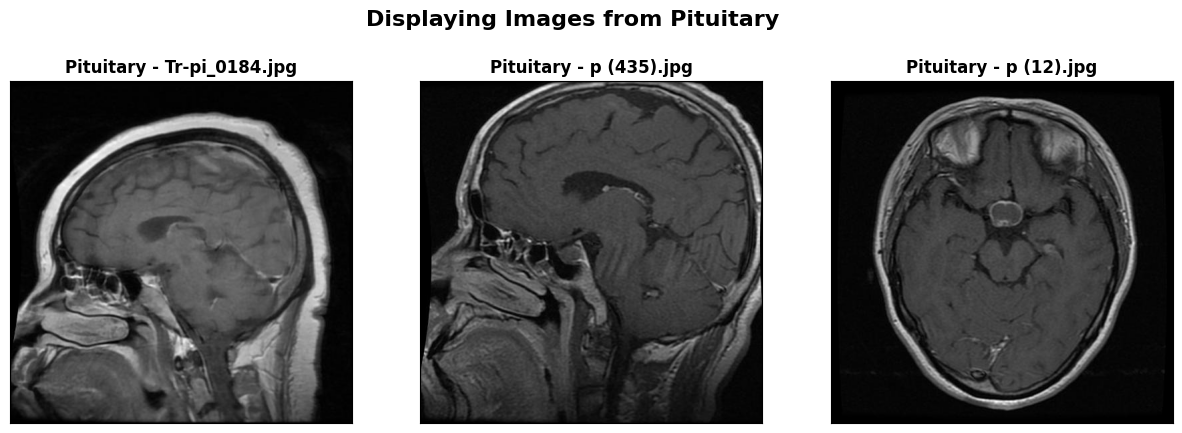

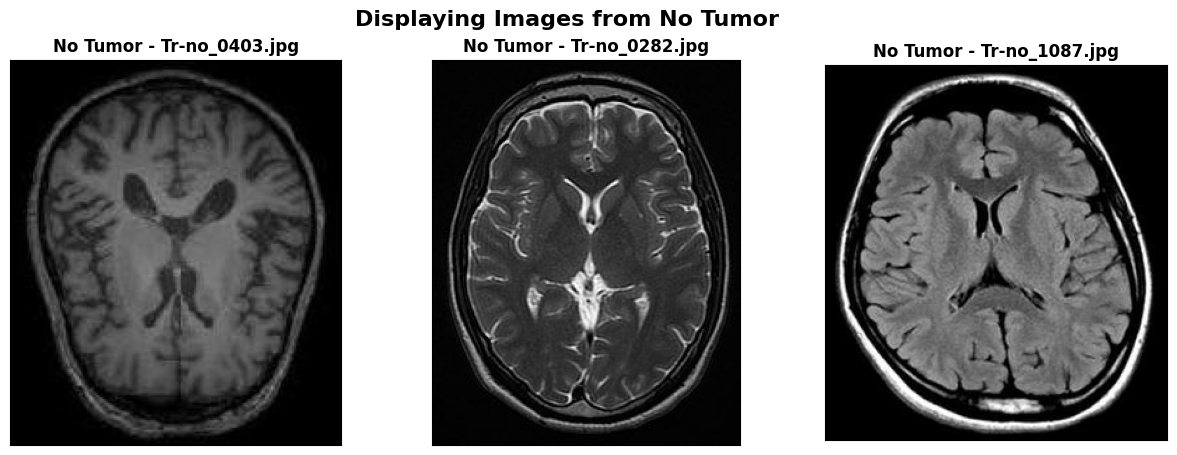

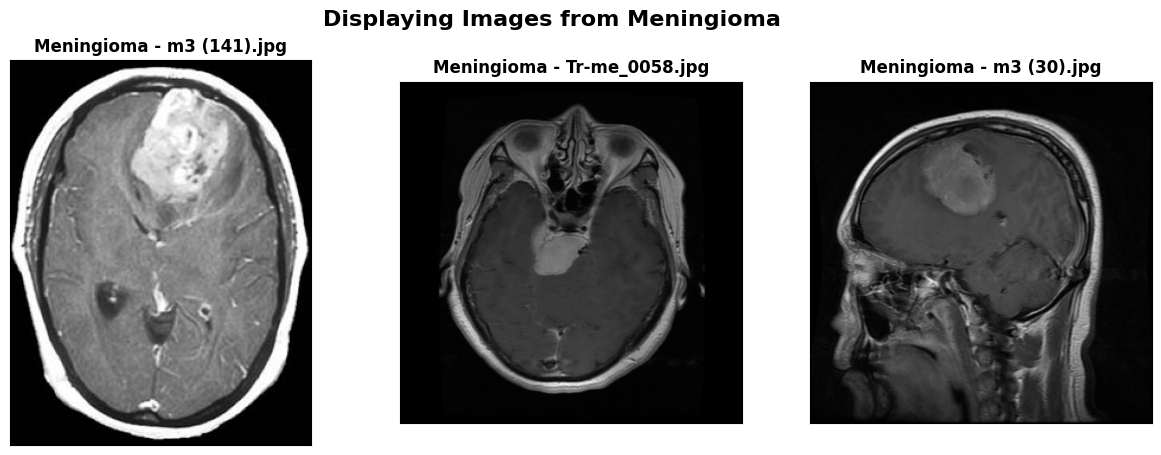

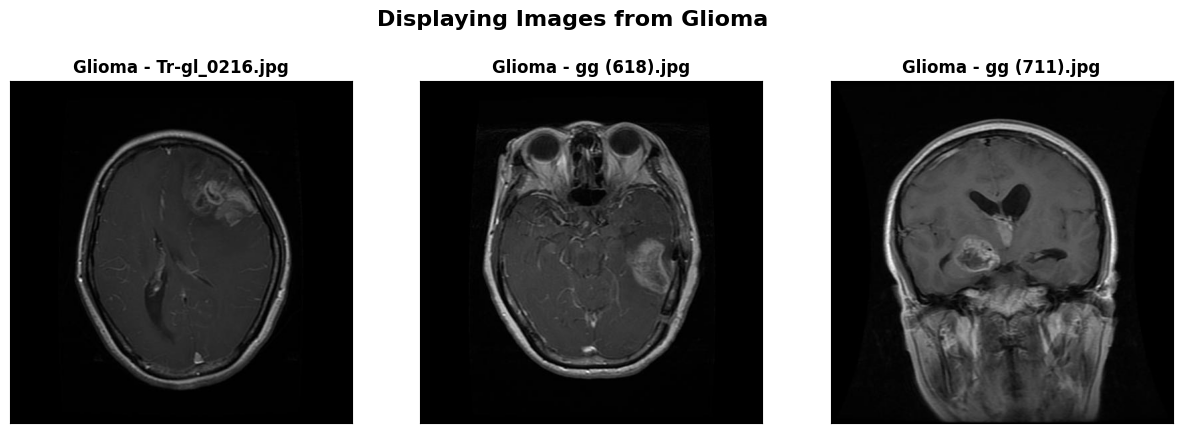

In [4]:
def display_random_images(directory, num_images=3):
    
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        images_path = os.path.join(directory, class_name, 'images')
        
        images = os.listdir(images_path)
        selected_images = random.sample(images, num_images)
        
        fig, axes = plt.subplots(1,3, figsize=(15,5))
        
        fig.suptitle(f"Displaying Images from {class_name}", fontsize=16, fontweight='bold')
        
        for ax, image in zip(axes, selected_images):
            image_path = os.path.join(images_path, image)
            img = mpimg.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{class_name} - {os.path.basename(image)}",fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            

display_random_images(train_path)
            

In [5]:
def images_preprocessing(images):
    processed_images = []
    for img in images:
        img_resized = cv2.resize(img, (640,640))
        processed_images.append(img_resized)
        
    return np.array(processed_images)

train_images = images_preprocessing(train_images)
val_images = images_preprocessing(val_images)

In [6]:
def count_images_in_folders(base_path):
    image_counts = []
    
    # Get all directories in the base_path
    main_directories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    for main_dir in main_directories:
        images_dir_path = os.path.join(base_path, main_dir, 'images')
        
        images = [f for f in os.listdir(images_dir_path) if os.path.isfile(os.path.join(images_dir_path, f))]
        
        print(f'\033[1mNumber of Images in {main_dir} : {len(images)}\033[0m')
        image_counts.append({'Class': main_dir, 'Count': len(images)})
    df = pd.DataFrame(image_counts).sort_values(by='Count',ascending=False)
    
    colors = ['#a6a832','#32a0a8', '#599173', '#bfbf95']
    fig = go.Figure(data=[go.Pie(labels=df['Class'], values = df['Count'], pull=[0.1,0,0,0],
                             textinfo ='label+percent', marker=dict(colors=colors, line=dict(color='black', width=2)))])
    fig.update_layout(paper_bgcolor='#dff2ef', plot_bgcolor='#dff2ef', title = 'Number of Images in Each Class', width=650, height=600, title_x=0.5, 
                  title_font_family="Times New Roman", title_font_color="#191e1f", title_font_size=30, font_family="Times New Roman", font_size=15)
    fig.show()
    return 

base_path = '/kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Train'
count_images_in_folders(base_path)

Number of Images in Pituitary : 1424
Number of Images in No Tumor : 711
Number of Images in Meningioma : 1449
Number of Images in Glioma : 1153


In [8]:
dataset_yaml = {
    'path': '/kaggle/input/mri-for-brain-tumor-with-bounding-boxes',
    'train': 'Train',
    'val': 'Val',
    'names': ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
}

with open('/kaggle/working/dataset_yaml.yaml', 'w') as file:
    yaml.dump(dataset_yaml, file)

In [9]:
model = YOLO('yolov8n.yaml')
model = YOLO('yolov8n.pt')
train_results = model.train(data='/kaggle/working/dataset_yaml.yaml' , epochs=5, imgsz=640)

100%|██████████| 6.25M/6.25M [00:00<00:00, 71.1MB/s]


Ultralytics YOLOv8.2.92 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/dataset_yaml.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_

100%|██████████| 755k/755k [00:00<00:00, 14.8MB/s]
2024-09-12 07:07:19,691	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-09-12 07:07:20,214	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /kaggle/input/mri-for-brain-tumor-with-bounding-boxes/Train/Glioma/labels... 4737 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4737/4737 [00:05<00:00, 812.58it/s]


...

        5/5      2.18G     0.8644     0.7438      1.114          1        640: 100%|██████████| 297/297 [00:50<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:02<00:00,  5.39it/s]

                   all        512        554      0.889      0.892      0.943      0.718



5 epochs completed in 0.078 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.92 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:04<00:00,  3.52it/s]


                   all        512        554      0.889      0.892      0.943      0.718
                Glioma        135        153       0.89      0.706      0.873      0.663
            Meningioma        140        142      0.839      0.986      0.971      0.784
              No Tumor         98         98      0.908       0.98      0.977      0.709
             Pituitary        154        161      0.917      0.895      0.952      0.715
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train



0: 640x640 1 Glioma, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 No Tumor, 7.4ms
Speed: 1.6ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Glioma, 7.5ms
Speed: 1.9ms preprocess, 7.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Glioma, 7.4ms
Speed: 2.3ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 No Tumor, 7.4ms
Speed: 2.0ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 Pituitarys, 7.4ms
Speed: 1.8ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Pituitary, 7.4ms
Speed: 2.4ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Glioma, 7.4ms
Speed: 1.8ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 64

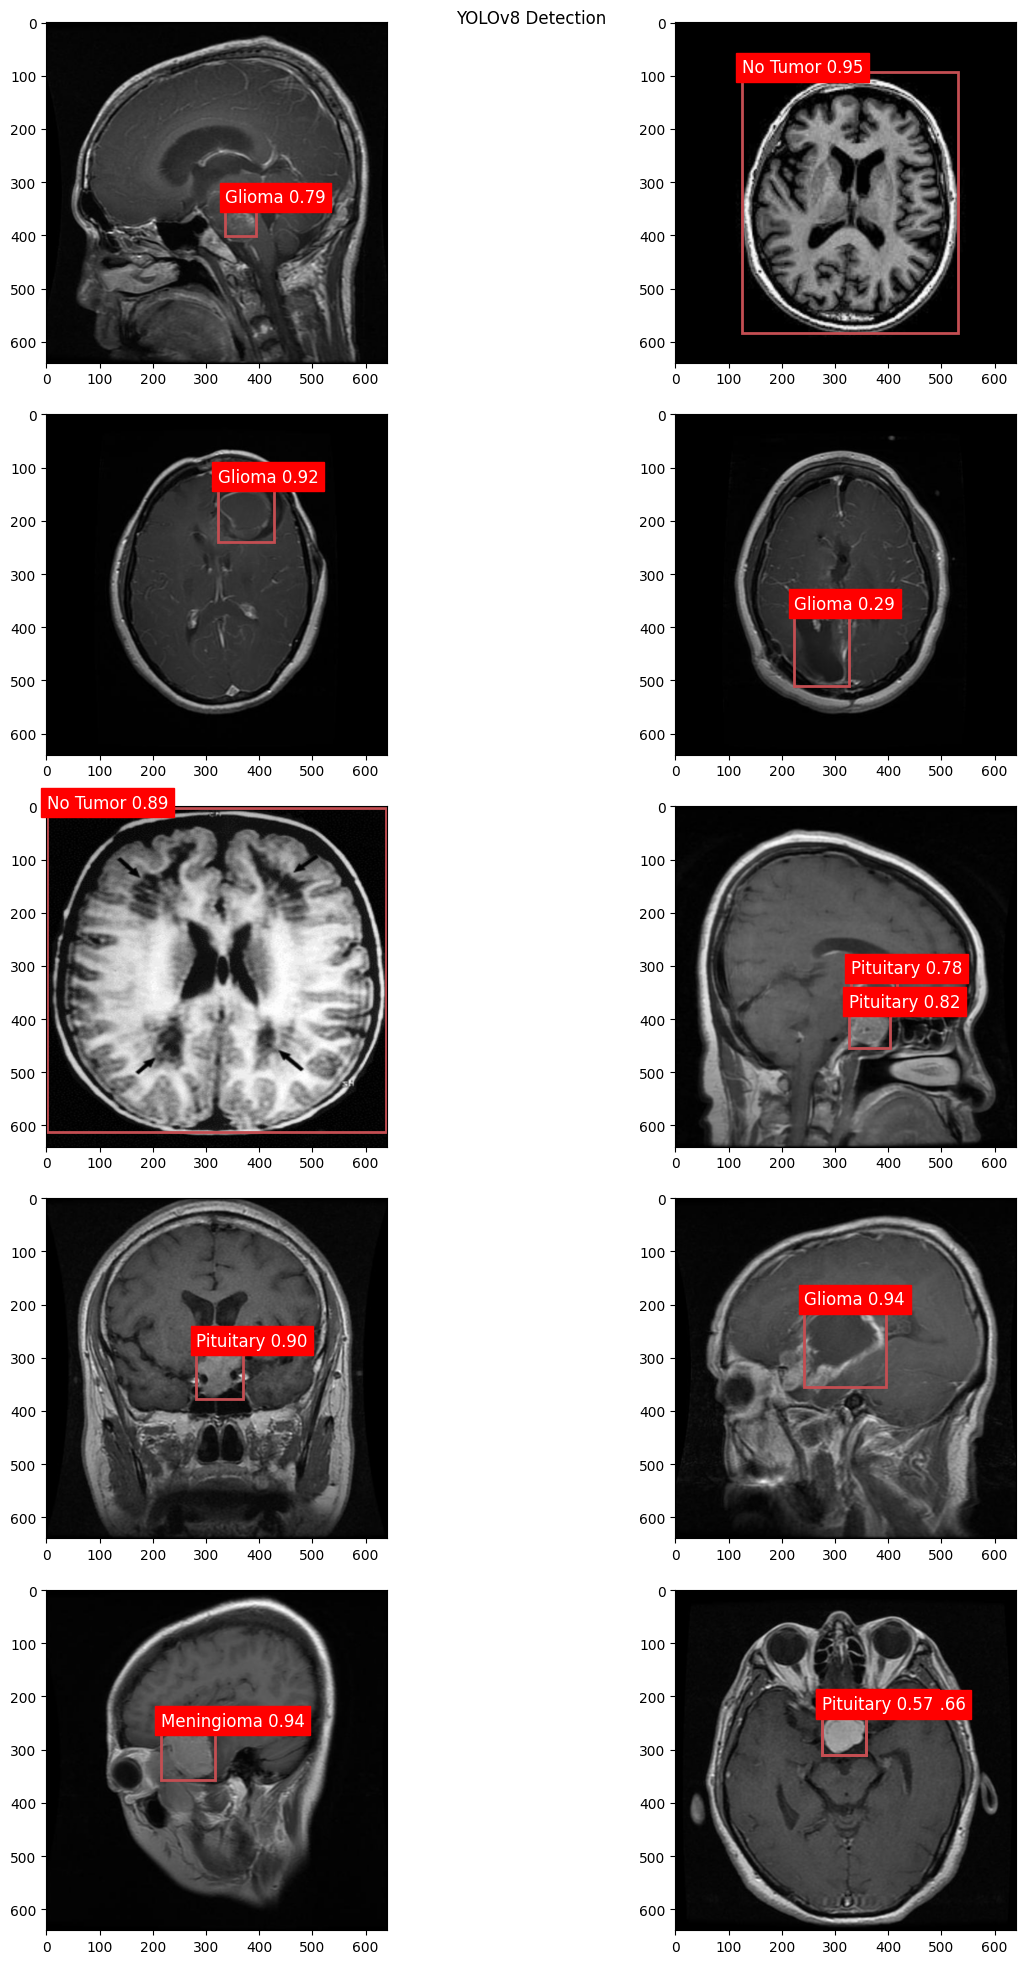

In [10]:
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

# Function to display detection results with highlighted parts
def display_samples(images, model):
    fig, axes = plt.subplots(5,2,figsize=(15, 20))
    fig.suptitle('YOLOv8 Detection')
    axes = axes.flatten()
    
    selected_images = random.sample(list(images), 10)
    
    for i, img in enumerate(selected_images):
        result = model.predict(img)[0]  
        ax=axes[i]
        ax.imshow(img)
#         ax = plt.gca()

        for detection in result.boxes:
            x1, y1, x2, y2 = detection.xyxy[0].cpu().numpy()
            conf = detection.conf[0].cpu().numpy()
            cls = detection.cls[0].cpu().numpy()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1, f"{classes[int(cls)]} {conf:.2f}", color='white', fontsize=12, backgroundcolor='red')
    plt.tight_layout() 

display_samples(val_images, model)